#                                    **KNN and PCA Assignment (Practcal)**

### **Q21 Train a KNN Classifier on the Iris dataset and print model accuracy**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def train_knn():
    # Load the Iris dataset
    iris = load_iris()
    X, y = iris.data, iris.target

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

    # Standardize the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Make predictions
    y_pred = knn.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy: {accuracy:.2f}')

if __name__ == "__main__":
    train_knn()

Model Accuracy: 0.97


### **Q22  Train a KNN Regressor on a synthetic dataset and evaluate using Mean Squared Error (MSE)**

Mean Squared Error: 0.0730


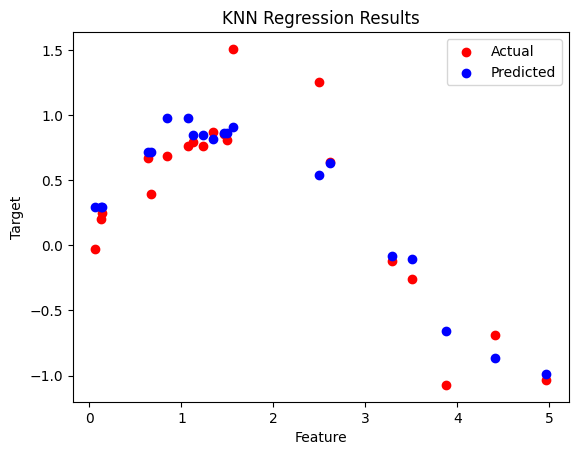

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Generate synthetic dataset
np.random.seed(2)
X = np.sort(5 * np.random.rand(100, 1), axis=0)  # Features
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # Target with noise

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# Plot results
plt.scatter(X_test, y_test, color='red', label='Actual')
plt.scatter(X_test, y_pred, color='blue', label='Predicted')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("KNN Regression Results")
plt.legend()
plt.show()


**Q23 Train a KNN Classifier using different distance metrics (Euclidean and Manhattan) and compare accuracy**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def train_knn_classifier(n_neighbors=5):
    # Load dataset
    iris = load_iris()
    X, y = iris.data, iris.target

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define distance metrics
    metrics = ['euclidean', 'manhattan']
    results = {}

    for metric in metrics:
        # Train KNN classifier
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
        knn.fit(X_train, y_train)

        # Predict on test set
        y_pred = knn.predict(X_test)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        results[metric] = accuracy

        print(f"Accuracy using {metric} distance: {accuracy:.4f}")

    return results

if __name__ == "__main__":
    train_knn_classifier()


Accuracy using euclidean distance: 0.9667
Accuracy using manhattan distance: 1.0000


**Q24  Train a KNN Classifier with different values of K and visualize decision boundaries**

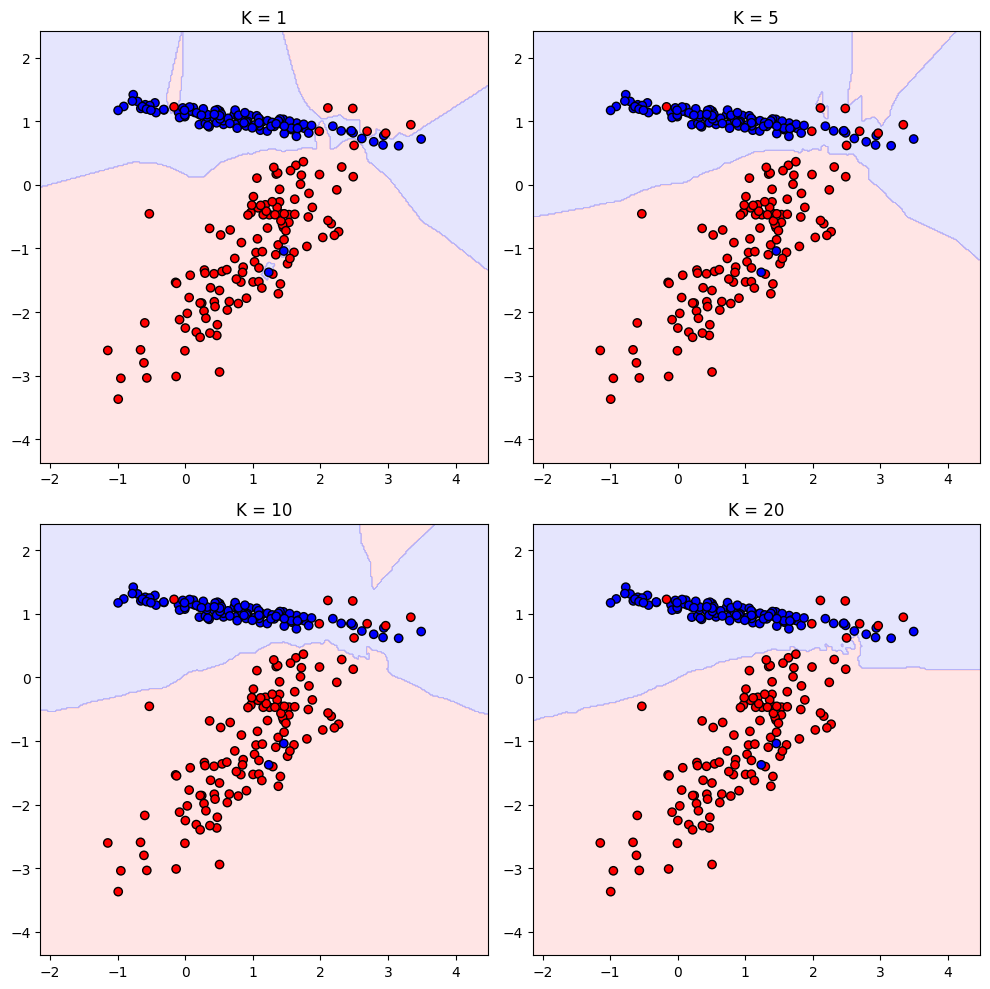

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

# Generate synthetic dataset

X, y = make_classification(n_samples = 300, n_features= 2,
                               n_informative=2, n_redundant=0,
                               n_clusters_per_class=1, n_classes=2,
                               random_state=2)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Function to plot decision boundaries
def plot_decision_boundary(ax, clf, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_background = ListedColormap(["#FFAAAA", "#AAAAFF","#AAAAFA"])
    cmap_points = ListedColormap(["#FF0000", "#0000FF","#0000FF" ])

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolor="k")
    ax.set_title(title)

# Train KNN models with different K values and visualize
k_values = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, k in zip(axes.ravel(), k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    plot_decision_boundary(ax, knn, X_train, y_train, f'K = {k}')

plt.tight_layout()
plt.show()

**Q25 Apply Feature Scaling before training a KNN model and compare results with unscaled data**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Generate synthetic dataset
from sklearn.datasets import make_classification
data, target = make_classification(n_samples=500, n_features=5, random_state=42)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Train KNN without feature scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f'Accuracy without Scaling: {accuracy_unscaled:.4f}')

# Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN with scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f'Accuracy with Scaling: {accuracy_scaled:.4f}')


Accuracy without Scaling: 0.9200
Accuracy with Scaling: 0.9300


**Q26 Train a PCA model on synthetic data and print the explained variance ratio for each component**

Explained Variance Ratio for each component:
Principal Component 1: 0.5571
Principal Component 2: 0.2132
Principal Component 3: 0.1820
Principal Component 4: 0.0420
Principal Component 5: 0.0057


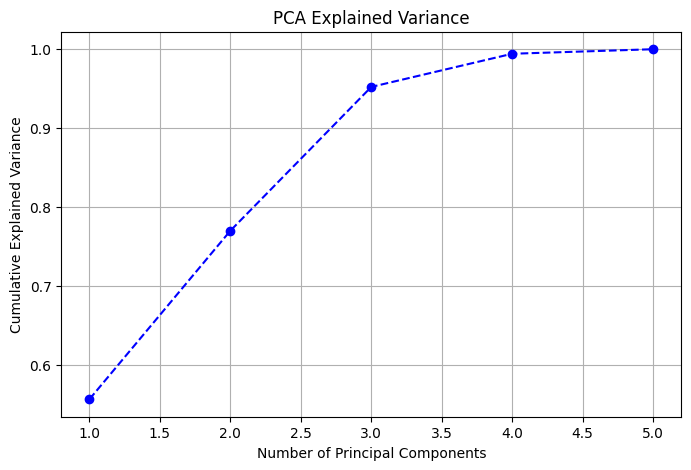

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic data
np.random.seed(2)
n_samples = 100
n_features = 5

# Create a dataset with correlated features
X = np.random.rand(n_samples, n_features)
X[:, 1] = X[:, 0] * 0.8 + np.random.rand(n_samples) * 0.2  # Correlated feature
X[:, 2] = X[:, 0] * 0.5 + np.random.rand(n_samples) * 0.3  # Correlated feature

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Print explained variance ratio
print("Explained Variance Ratio for each component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {ratio:.4f}")

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_features + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

**Q27 Apply PCA before training a KNN Classifier and compare accuracy with and without PCA**

Accuracy without PCA: 0.9667
Accuracy with PCA: 0.9000


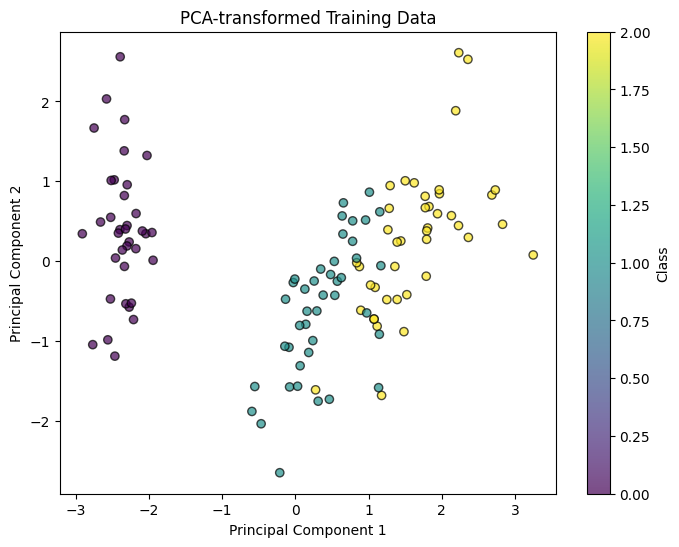

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate KNN without PCA
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
accuracy_without_pca = accuracy_score(y_test, y_pred)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 principal components
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train and evaluate KNN with PCA
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_with_pca = accuracy_score(y_test, y_pred_pca)

# Print the accuracy results
print(f"Accuracy without PCA: {accuracy_without_pca:.4f}")
print(f"Accuracy with PCA: {accuracy_with_pca:.4f}")

# Visualizing the PCA-reduced dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', edgecolors='k', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA-transformed Training Data")
plt.colorbar(label="Class")
plt.show()


**Q28  Perform Hyperparameter Tuning on a KNN Classifier using GridSearchCV**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

# Create a pipeline with StandardScaler and KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalize the data
    ('knn', KNeighborsClassifier())  # KNN model
])

# Define the hyperparameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],  # Number of neighbors
    'knn__weights': ['uniform', 'distance'],  # Weight function
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metric
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test Set Accuracy:", test_accuracy)

Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 0.95
Test Set Accuracy: 0.9666666666666667


  **Q29 Train KNN Classifier and check the number of misclassified samples**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN classifier
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predict on test set
y_pred = knn.predict(X_test)

# Compute number of misclassified samples
misclassified_samples = (y_test != y_pred).sum()

# Print results
print(f"Number of misclassified samples: {misclassified_samples}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Number of misclassified samples: 1
Accuracy: 0.97


**Q30 Train a PCA model and visualize the cumulative explained variance**

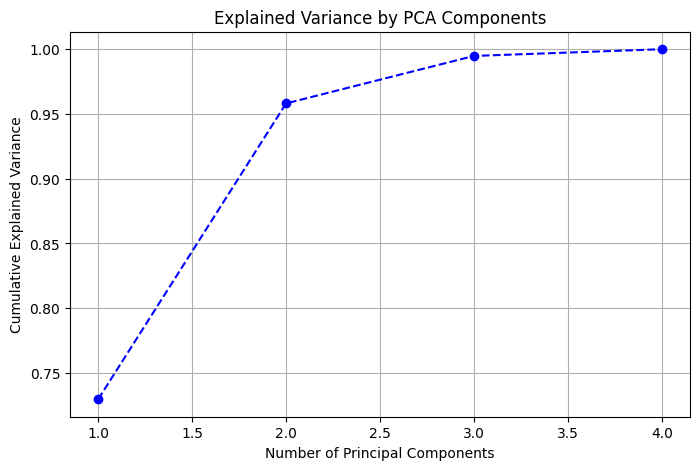

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load dataset (Iris dataset for example)
data = load_iris()
X = data.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Compute cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()


**Q31 Train a KNN Classifier using different values of the weights parameter (uniform vs. distance) and compare accuracy**

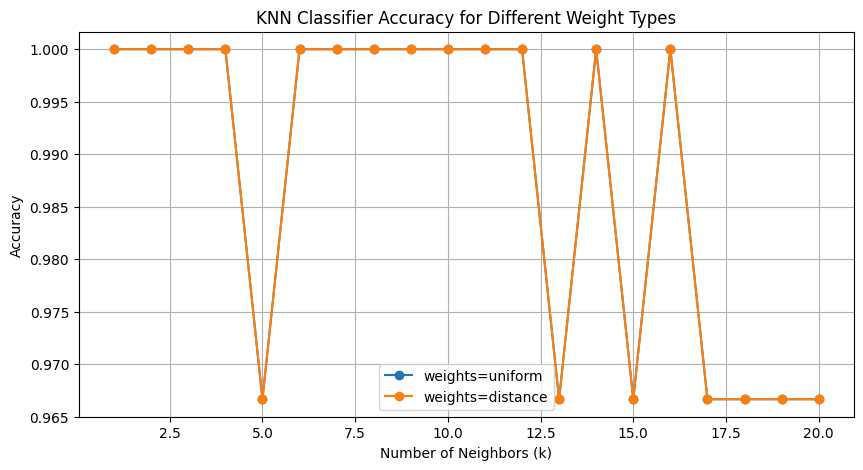

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize features (recommended for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define different weight types
weight_types = ['uniform', 'distance']
k_values = range(1, 21)  # Testing k from 1 to 20

# Store accuracy results
accuracy_results = {weight: [] for weight in weight_types}

for weight in weight_types:
    for k in k_values:
        # Train KNN classifier
        knn = KNeighborsClassifier(n_neighbors=k, weights=weight)
        knn.fit(X_train, y_train)

        # Predict and evaluate
        y_pred = knn.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_results[weight].append(accuracy)

# Plot accuracy results
plt.figure(figsize=(10, 5))
for weight in weight_types:
    plt.plot(k_values, accuracy_results[weight], marker='o', label=f'weights={weight}')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Classifier Accuracy for Different Weight Types')
plt.legend()
plt.grid()
plt.show()


**Q32 Train a KNN Regressor and analyze the effect of different K values on performance**

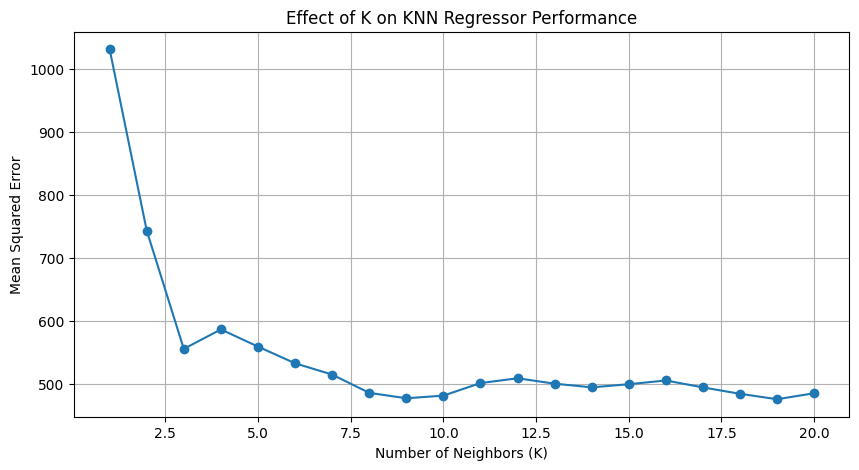

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

# Generate synthetic regression dataset
X, y = make_regression(n_samples=200, n_features=1, noise=20, random_state=2)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# List of K values to evaluate
k_values = range(1, 21)
mse_values = []

# Train and evaluate KNN regressor for different K values
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

# Plot MSE vs. K values
plt.figure(figsize=(10, 5))
plt.plot(k_values, mse_values, marker='o', linestyle='-')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of K on KNN Regressor Performance')
plt.grid(True)
plt.show()


**Q33  Implement KNN Imputation for handling missing values in a dataset**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

# Sample dataset with missing values
data = {
    'A': [1, 2, np.nan, 4, 5],
    'B': [3, np.nan, 1, 6, 2],
    'C': [np.nan, 5, 2, 8, 7]
}
df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# Define KNN Imputer with k=3
knn_imputer = KNNImputer(n_neighbors=3)

# Perform imputation
imputed_data = knn_imputer.fit_transform(df)

# Convert back to DataFrame
imputed_df = pd.DataFrame(imputed_data, columns=df.columns)

print("\nDataset after KNN Imputation:")
print(imputed_df)


Original Dataset:
     A    B    C
0  1.0  3.0  NaN
1  2.0  NaN  5.0
2  NaN  1.0  2.0
3  4.0  6.0  8.0
4  5.0  2.0  7.0

Dataset after KNN Imputation:
          A         B         C
0  1.000000  3.000000  4.666667
1  2.000000  3.666667  5.000000
2  2.666667  1.000000  2.000000
3  4.000000  6.000000  8.000000
4  5.000000  2.000000  7.000000


**Q34  Train a PCA model and visualize the data projection onto the first two principal components**

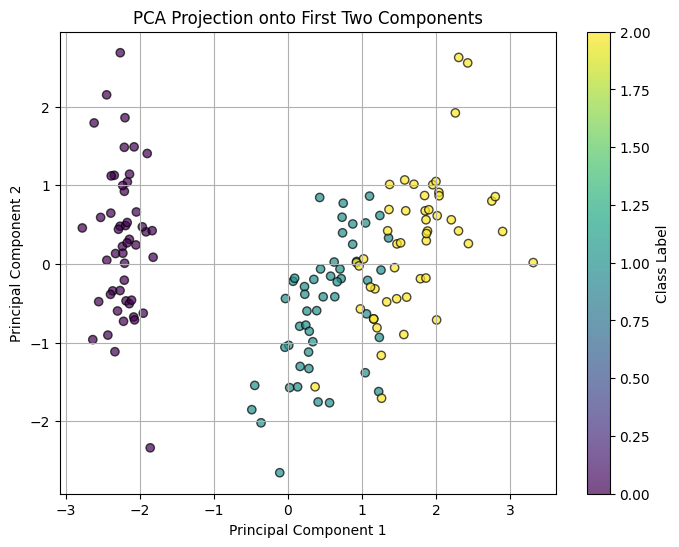

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load the dataset (Iris dataset as an example)
data = load_iris()
X = data.data
y = data.target

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the first two principal components
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection onto First Two Components')
plt.colorbar(scatter, label='Class Label')
plt.grid(True)
plt.show()


**Q35  Train a KNN Classifier using the KD Tree and Ball Tree algorithms and compare performance**

In [ ]:
import numpy as np
import time
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_classification(n_samples=5000, n_features=20, n_classes=2, random_state=2)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Define KNN classifier parameters
k = 5  # Number of neighbors

# Train and evaluate using KD Tree
kd_tree_knn = KNeighborsClassifier(n_neighbors=k, algorithm='kd_tree')
kd_start_time = time.time()
kd_tree_knn.fit(X_train, y_train)
kd_predictions = kd_tree_knn.predict(X_test)
kd_time = time.time() - kd_start_time
kd_accuracy = accuracy_score(y_test, kd_predictions)

# Train and evaluate using Ball Tree
ball_tree_knn = KNeighborsClassifier(n_neighbors=k, algorithm='ball_tree')
ball_start_time = time.time()
ball_tree_knn.fit(X_train, y_train)
ball_predictions = ball_tree_knn.predict(X_test)
ball_time = time.time() - ball_start_time
ball_accuracy = accuracy_score(y_test, ball_predictions)

# Print results
print("Performance Comparison:")
print(f"KD Tree - Accuracy: {kd_accuracy:.4f}, Time: {kd_time:.4f} seconds")
print(f"Ball Tree - Accuracy: {ball_accuracy:.4f}, Time: {ball_time:.4f} seconds")


Performance Comparison:
KD Tree - Accuracy: 0.8730, Time: 0.2450 seconds
Ball Tree - Accuracy: 0.8730, Time: 0.1519 seconds


**Q36  Train a PCA model on a high-dimensional dataset and visualize the Scree plot**

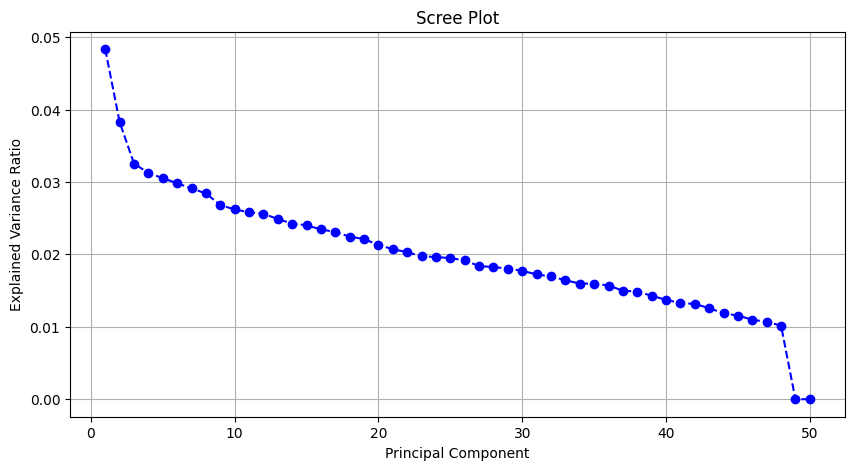

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# Generate a high-dimensional synthetic dataset
X, _ = make_classification(n_samples=500, n_features=50, random_state=2)

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot the Scree plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='b')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid()
plt.show()


**Q37  Train a KNN Classifier and evaluate performance using Precision, Recall, and F1-Score**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the KNN classifier
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=data.target_names)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)


Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       1.00      0.88      0.93         8
   virginica       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



**Q38  Train a PCA model and analyze the effect of different numbers of components on accuracy**

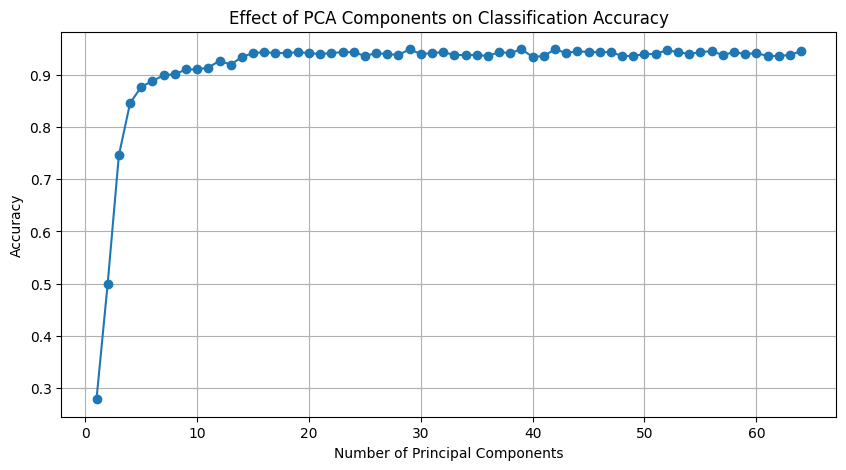

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=2)

# Test different numbers of principal components
num_components = range(1, X.shape[1] + 1)
accuracies = []

for n in num_components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Train classifier
    clf = RandomForestClassifier(random_state=2)
    clf.fit(X_train_pca, y_train)

    # Predict and evaluate
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(num_components, accuracies, marker='o', linestyle='-')
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.title('Effect of PCA Components on Classification Accuracy')
plt.grid()
plt.show()


**Q39 Train a KNN Classifier with different leaf_size values and compare accuracy**

Leaf Size: 1, Accuracy: 0.9500
Leaf Size: 5, Accuracy: 0.9500
Leaf Size: 10, Accuracy: 0.9500
Leaf Size: 20, Accuracy: 0.9500
Leaf Size: 30, Accuracy: 0.9500
Leaf Size: 40, Accuracy: 0.9500
Leaf Size: 50, Accuracy: 0.9500


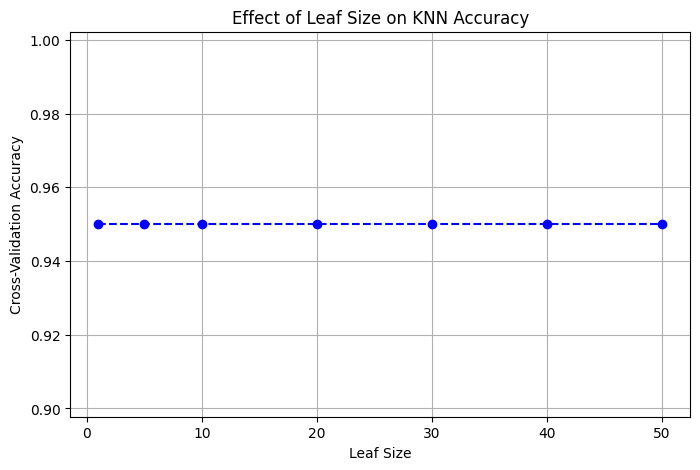

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Define different leaf_size values to test
leaf_sizes = [1, 5, 10, 20, 30, 40, 50]
accuracies = []

# Train and evaluate KNN with different leaf_size values
for leaf_size in leaf_sizes:
    knn = KNeighborsClassifier(n_neighbors=5, leaf_size=leaf_size)
    scores = cross_val_score(knn, X_train, y_train, cv=5)  # 5-fold cross-validation
    mean_accuracy = scores.mean()
    accuracies.append(mean_accuracy)
    print(f'Leaf Size: {leaf_size}, Accuracy: {mean_accuracy:.4f}')

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(leaf_sizes, accuracies, marker='o', linestyle='--', color='b')
plt.xlabel('Leaf Size')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Effect of Leaf Size on KNN Accuracy')
plt.grid()
plt.show()


**Q40 Train a PCA model and visualize how data points are transformed before and after PCA**

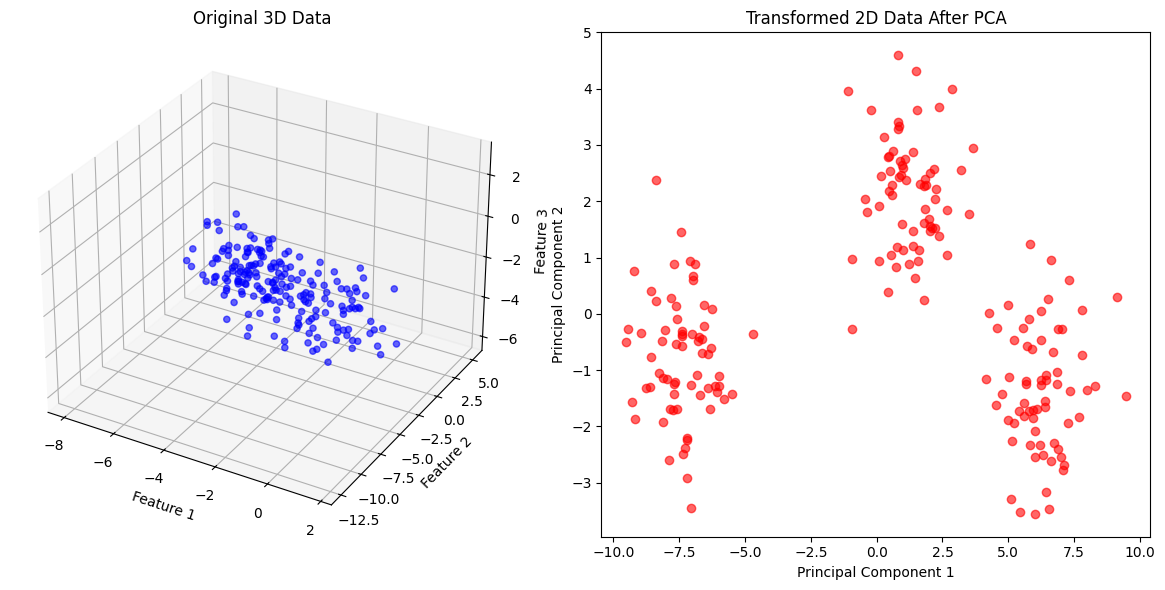

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

# Generate synthetic 3D data
np.random.seed(42)
X, _ = make_blobs(n_samples=200, centers=3, n_features=3, random_state=2)

# Visualize original 3D data
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', alpha=0.6)
ax.set_title("Original 3D Data")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

# Apply PCA to reduce dimensionality from 3D to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualize transformed 2D data
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c='red', alpha=0.6)
ax2.set_title("Transformed 2D Data After PCA")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

**Q41  Train a KNN Classifier on a real-world dataset (Wine dataset) and print classification report**

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features by scaling to unit variance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



**Q42 Train a KNN Regressor and analyze the effect of different distance metrics on prediction error**

MSE using euclidean: 1.1420
MSE using manhattan: 1.0174
MSE using minkowski: 1.1420


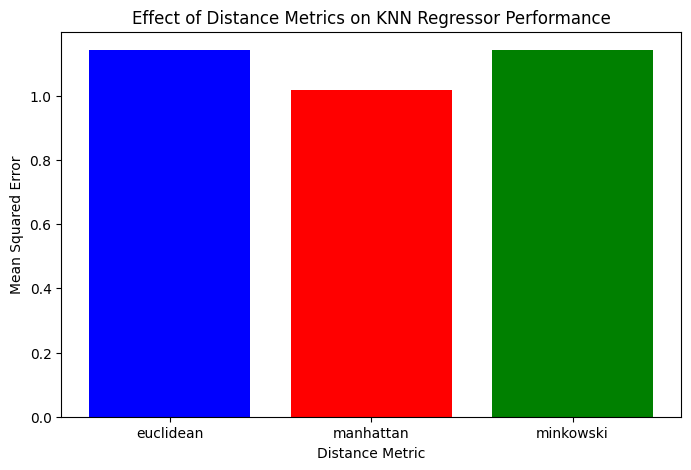

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Distance metrics to evaluate
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

# Store results
mse_results = {}

for metric in distance_metrics:
    # Train KNN regressor
    knn = KNeighborsRegressor(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)

    # Predict on test set
    y_pred = knn.predict(X_test)

    # Compute MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_results[metric] = mse
    print(f'MSE using {metric}: {mse:.4f}')

# Plot results
plt.figure(figsize=(8, 5))
plt.bar(mse_results.keys(), mse_results.values(), color=['blue', 'red', 'green'])
plt.xlabel('Distance Metric')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Distance Metrics on KNN Regressor Performance')
plt.show()

**Q43  Train a KNN Classifier and evaluate using ROC-AUC score**

ROC-AUC Score: 0.9000


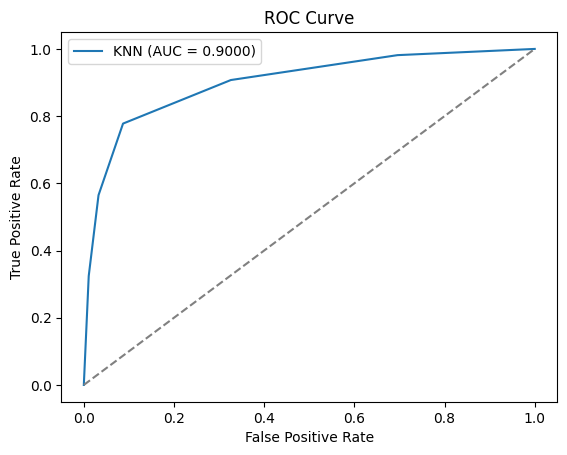

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.datasets import make_classification

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=2)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict probabilities
y_probs = knn.predict_proba(X_test)[:, 1]

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_probs)
print(f'ROC-AUC Score: {roc_auc:.4f}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


**Q44  Train a PCA model and visualize the variance captured by each principal component**

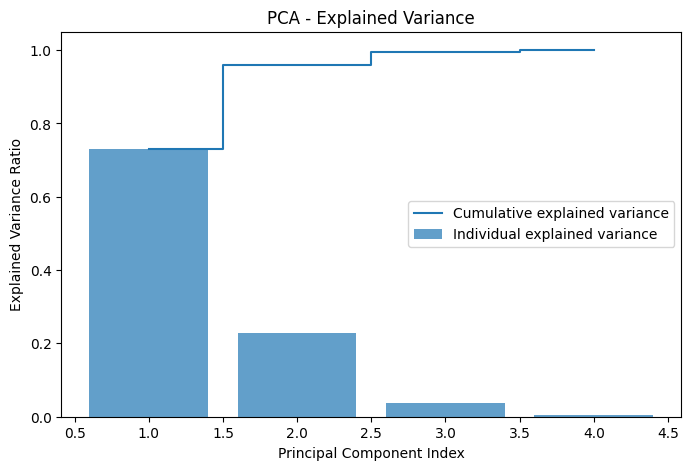

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load dataset (Iris dataset as an example)
data = load_iris()
X = data.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Plot the variance explained by each component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', label='Individual explained variance')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Cumulative explained variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Explained Variance')
plt.legend()
plt.show()


**Q45 Train a KNN Classifier and perform feature selection before training**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Generate synthetic dataset (Replace with real dataset)
np.random.seed(42)
X = np.random.rand(200, 10)  # 200 samples, 10 features
y = np.random.randint(0, 2, 200)  # Binary classification

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Feature selection using SelectKBest
k = 5  # Number of top features to select
selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Standardize the selected features
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_selected, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Get selected feature indices
selected_features = selector.get_support(indices=True)
print(f'Selected feature indices: {selected_features}')


Accuracy: 0.4000
Selected feature indices: [1 5 7 8 9]


**Q46  Train a PCA model and visualize the data reconstruction error after reducing dimensions**

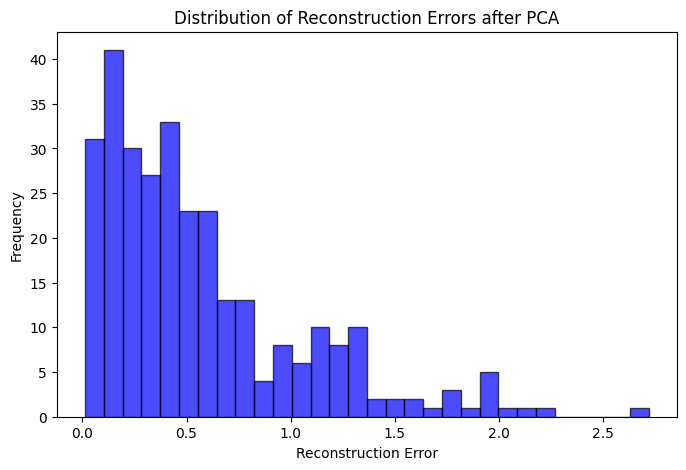

Average reconstruction error: 0.5726


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

# Generate synthetic data
np.random.seed(42)
X, _ = make_blobs(n_samples=300, n_features=5, centers=3, random_state=42)

# Define number of principal components
n_components = 2
pca = PCA(n_components=n_components)

# Fit PCA model and transform the data
X_pca = pca.fit_transform(X)

# Reconstruct the data from PCA components
X_reconstructed = pca.inverse_transform(X_pca)

# Compute reconstruction error (Mean Squared Error)
reconstruction_error = np.mean((X - X_reconstructed) ** 2, axis=1)

# Plot the reconstruction error
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors after PCA")
plt.show()

print(f"Average reconstruction error: {np.mean(reconstruction_error):.4f}")

**Q47  Train a KNN Classifier and visualize the decision boundary**

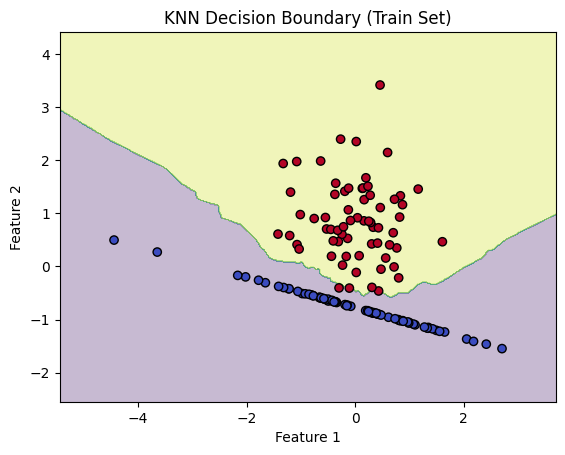

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Generate synthetic dataset
X, y = make_classification(n_samples=200, n_features=2, n_classes=2, n_redundant=0, n_clusters_per_class=1, random_state=2)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Visualize decision boundary
plot_decision_boundary(X_train, y_train, knn, title="KNN Decision Boundary (Train Set)")


**Q48 Train a PCA model and analyze the effect of different numbers of components on data variance**

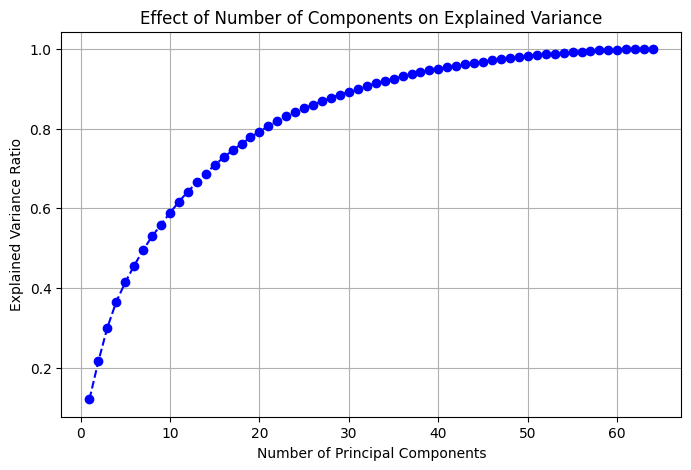

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# Load dataset
digits = load_digits()
X = digits.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define a range of components to test
num_components = range(1, X.shape[1] + 1)
explained_variance = []

# Train PCA models with different numbers of components
for n in num_components:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

# Plot the explained variance vs. number of components
plt.figure(figsize=(8, 5))
plt.plot(num_components, explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Effect of Number of Components on Explained Variance')
plt.grid()
plt.show()
